<a href="https://colab.research.google.com/github/anaberereta-hue/Trabajos-Colab/blob/main/Anis_taller_transformaciones_astro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00


In [2]:
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import make_lupton_rgb


In [3]:
#descargar una imagen del telescopio SDSS de una galaxia con coordenadas ra y dec, el tamaño de la imagen es de 30 arcsec
coord = SkyCoord(
    ra=201.649435*u.deg,
    dec=32.760895*u.deg,
    frame='icrs'
)

# Descargar imagen
images = SDSS.get_images(
    coordinates=coord,
    band='r'
)

hdu = images[0][0]

data = hdu.data
wcs = WCS(hdu.header)

# Recorte de 30 arcsec x 30 arcsec
cutout = Cutout2D(
    data,
    position=coord,
    size=(30*u.arcsec, 30*u.arcsec),
    wcs=wcs
)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


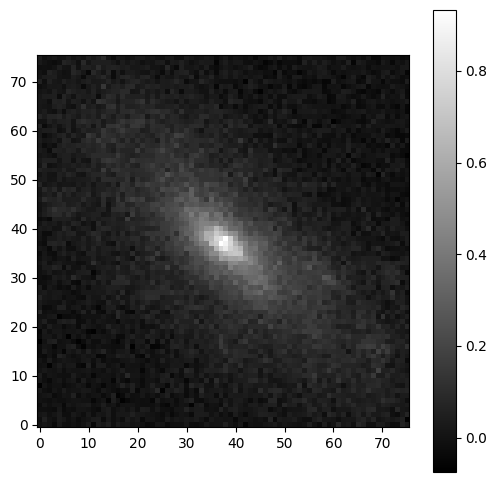

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(cutout.data, origin='lower', cmap='gray')
plt.colorbar()
plt.show()

USA LA LIBRERIA MATPLOTLIB Y GRAFICA LA GALAXIA CON DIFERENTES MAPAS DE COLORES

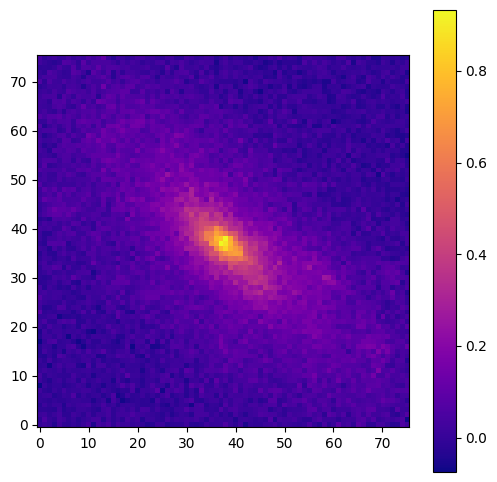

In [16]:
plt.figure(figsize=(6,6))
plt.imshow(cutout.data, origin='lower', cmap='plasma')
plt.colorbar()
plt.show()

In [6]:
#los datos astronómicos vienen en un formato fits que almacena los metadatos asi como los datos
#en este código estamos seleccionando únicamente los datos de la imagen
image = cutout.data
display(image)

array([[-0.00361633,  0.01672363,  0.00146866, ..., -0.02398682,
         0.0625    ,  0.02688599],
       [-0.01379395,  0.05230713,  0.00146675, ...,  0.03198242,
         0.05743408, -0.06469727],
       [ 0.01164246,  0.02182007, -0.00871277, ..., -0.02401733,
         0.02178955,  0.07275391],
       ...,
       [-0.01396179, -0.00886536, -0.01396179, ..., -0.00889587,
         0.02163696,  0.0267334 ],
       [ 0.0267334 ,  0.001297  , -0.01396179, ...,  0.00636292,
        -0.00891113,  0.02163696],
       [ 0.04199219, -0.00888062,  0.01145935, ..., -0.0038147 ,
        -0.03942871, -0.02926636]], dtype='>f4')

A partir de los datos de la imagen estima la media, mediana, y desviación estándar de la imagen, también el valor mínimo y máximo

In [7]:
print("Media: ", np.mean(image))
print("Mediana: ", np.median(image))
print("Desviación estándar: ", np.std(image))
print("Valor mínimo: ", np.min(image))
print("Valor máximo: ", np.max(image))

Media:  0.06335631
Mediana:  0.042053223
Desviación estándar:  0.09240379
Valor mínimo:  -0.0748291
Valor máximo:  0.9326172


Grafica el histograma original de los datos de la imagen, cómo es la distribución?

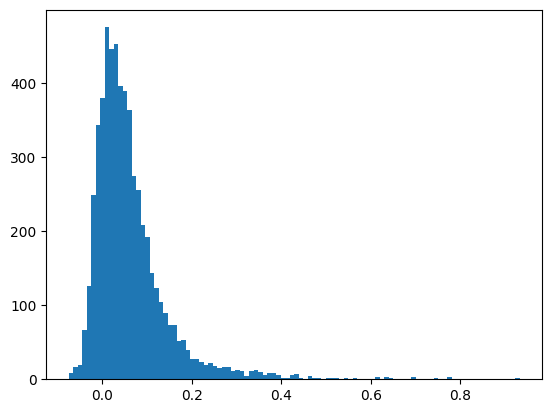

In [17]:
#Grafica el histograma original de los datos de la imagen, cómo es la distribución?
plt.hist(image.flatten(), bins=100)
plt.show()


Una de las transformaciones más empleadas en astronomía es la raíz cuadrada, transforma los datos empleando np.sqrt() y grafica la imagen transformada y su histograma.

Una de las transformaciones más conocidas es la de logarítmo, transforma los datos empleando np.log1p() o np.log10(). Muestra la nueva gráfica y su histograma.

Construyen una gráfica que muestre las tres transformaciones. ¿cuál es la diferencia en las imágenes?

Construyen una gráfica que muestre los tres histogramas . ¿cuál es la diferencia en los histogramas?

Estas son las transformaciones más conocidas, pero existen más, investiga una transformación distinta y contruye la gráfica y su histograma.

Las transformaciones en astronomía se emplean para destacar las partes más tenues de los objetos. ¿Con cuál de todas te quedarías?

En astronomía para construir imágenes se emplean diferentes filtros,
* u → estrellas jóvenes calientes, formación estelar
* g → regiones azules, población joven
* r → estructura estelar general de galaxias
* i → bulbos galácticos, estrellas viejas
* z → polvo y componentes más rojos / galaxias lejanas


In [9]:
#este código permite descargar los datos de los otros filtros
bands = ['u', 'g', 'i','z']
cutouts = {}

for band in bands:
    img = SDSS.get_images(coordinates=coord, band=band)[0][0]

    data = img.data
    wcs = WCS(img.header)

    cut = Cutout2D(
        data,
        position=coord,
        size=(30*u.arcsec, 30*u.arcsec),
        wcs=wcs
    ).data

    cutouts[band] = cut

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


In [10]:
cutouts

{'u': array([[ 0.00693512, -0.05224609,  0.04077148, ..., -0.03533936,
          0.06616211,  0.06616211],
        [-0.08605957, -0.00152016,  0.00693512, ..., -0.04382324,
         -0.10302734, -0.00151443],
        [ 0.0322876 , -0.01843262,  0.00693512, ...,  0.00694275,
         -0.00151443, -0.00151443],
        ...,
        [ 0.07458496, -0.02685547, -0.07763672, ..., -0.00994873,
          0.09155273,  0.03234863],
        [-0.03533936, -0.02685547, -0.05224609, ...,  0.02389526,
         -0.03533936,  0.04925537],
        [ 0.01542664,  0.01542664,  0.03234863, ..., -0.07763672,
          0.02389526, -0.00148201]], dtype='>f4'),
 'g': array([[ 0.02593994, -0.01420593, -0.03430176, ..., -0.01422119,
          0.01254272,  0.00250626],
        [ 0.00921631,  0.02929688,  0.02593994, ..., -0.00083923,
          0.00920105,  0.00585175],
        [-0.01086426, -0.02090454, -0.00416565, ...,  0.02593994,
          0.03265381, -0.00084019],
        ...,
        [ 0.01593018,  0.019287

Selecciona uno de los otros filtros y realiza la transformación de raíz cuadrada y logarítmica. Que puedes concluir de la transformación?